In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [8]:
data_dir = r"D:\SmartVision\DataSets\smartvision_dataset\classification"

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/val",
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/test",
    image_size=img_size,
    batch_size=batch_size
)

Found 1820 files belonging to 26 classes.
Found 390 files belonging to 26 classes.
Found 390 files belonging to 26 classes.


In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


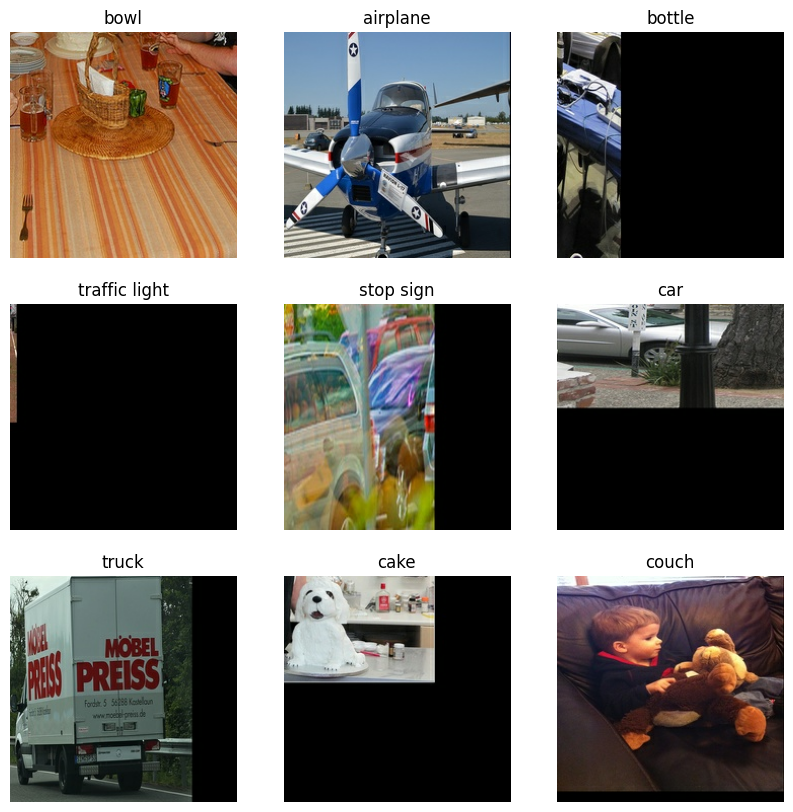

In [11]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

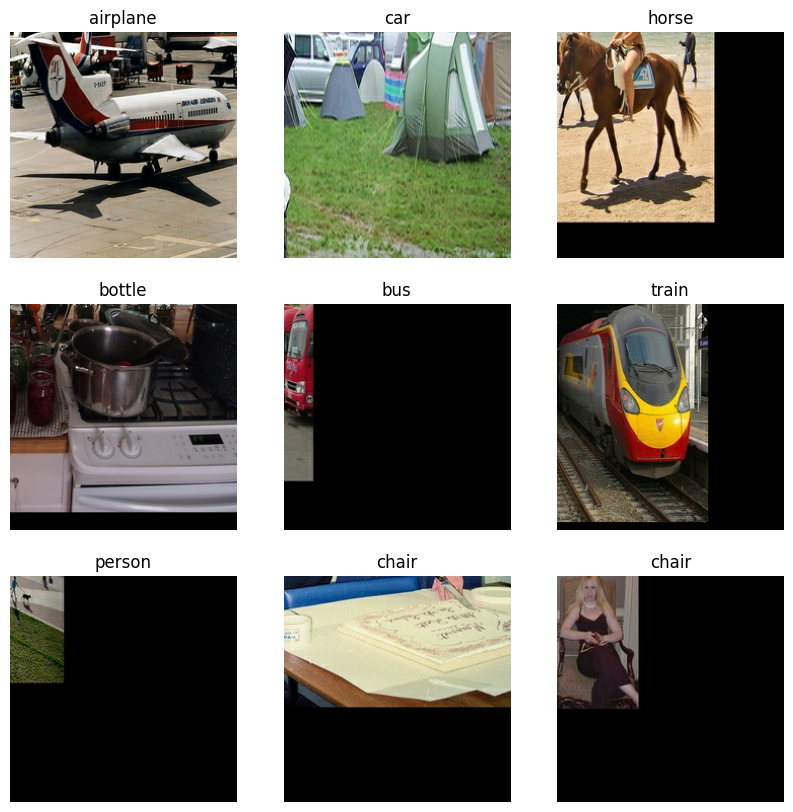

In [13]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

(np.float64(-0.5), np.float64(380.5), np.float64(499.5), np.float64(-0.5))

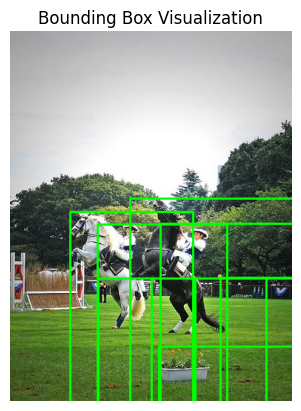

In [15]:
import cv2
import matplotlib.pyplot as plt

label_path = r"D:\SmartVision\DataSets\smartvision_dataset\detection\labels\image_000001.txt"
img_path = r"D:\SmartVision\DataSets\smartvision_dataset\detection\images\image_000001.jpg"

img = cv2.imread(img_path)
h, w, _ = img.shape

with open(label_path) as f:
    for line in f.readlines():
        cls, x, y, bw, bh = map(float, line.split())
        
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)
        
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Bounding Box Visualization")
plt.axis("off")